In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

# ===== USER SETTINGS =====
extxyz_path = "/Users/tony/spiedie/Projects/uma-validation/SP/toluene/UMA/uma-s/sp_uma.extxyz"   # <-- change
per_atom_energy = True                 # True -> eV/atom, False -> total eV
outdir = Path("plots")
outdir.mkdir(exist_ok=True)

In [2]:
frames = read(extxyz_path, index=":")
len(frames)

100

In [3]:
# Inspect the first frame to confirm keys
a0 = frames[0]
print("info keys:", list(a0.info.keys()))
print("arrays:", list(a0.arrays.keys()))
print("N atoms:", len(a0))

info keys: ['REF_energy', 'potaudit_job', 'charge', 'spin', 'uma_energy']
arrays: ['numbers', 'positions', 'REF_forces', 'uma_forces']
N atoms: 675


In [34]:

def force_parity_plot(frames, ref_key="REF_forces", pred_key="uma_forces",
                      n_points=50000, seed=0, title="Forces parity: UMA vs VASP"):
    # collect all forces
    Fref_list, Fpred_list = [], []
    for a in frames:
        if ref_key not in a.arrays or pred_key not in a.arrays:
            raise RuntimeError(f"Missing arrays in a frame. Have: {list(a.arrays.keys())}")
        Fref_list.append(np.asarray(a.arrays[ref_key], float))
        Fpred_list.append(np.asarray(a.arrays[pred_key], float))

    Fref = np.vstack(Fref_list)   # (Natoms_total, 3)
    Fpred = np.vstack(Fpred_list)

    # flatten to components (Fx,Fy,Fz)
    x = Fref.reshape(-1)
    y = Fpred.reshape(-1)

    # sample for plotting
    rng = np.random.default_rng(seed)
    n = x.size
    idx = rng.choice(n, size=min(n_points, n), replace=False)
    xs = x[idx]
    ys = y[idx]

    # metrics on the sampled set (fast) - change to full set if you want
    d = ys - xs
    rmse = float(np.sqrt(np.mean(d*d)))
    mae  = float(np.mean(np.abs(d)))
    # R^2
    ss_res = float(np.sum((ys - xs)**2))
    ss_tot = float(np.sum((ys - np.mean(ys))**2))
    r2 = 1.0 - ss_res/ss_tot if ss_tot > 0 else float("nan")

    # parity line range
    mn = float(min(xs.min(), ys.min()))
    mx = float(max(xs.max(), ys.max()))

    plt.figure(figsize=(6, 6))
    plt.scatter(xs, ys, s=4)
    plt.plot([mn, mx], [mn, mx], color="black", linestyle="-")
    plt.xlabel("PBE-D3(eV/Å)",fontsize=14)
    plt.ylabel("UMA-s-1p1 (eV/Å)",fontsize=14)
    plt.title(f"\nRMSE={rmse:.4g} eV/Å, MAE={mae:.4g} eV/Å, R²={r2:.4g} ")
    plt.tick_params(axis='both', labelsize=12)
    plt.tight_layout()
    plt.savefig(f"plots/force_pbe_uma-s1p1.png",dpi=500)

    return {"rmse": rmse, "mae": mae, "r2": r2, "n": int(len(xs))}



{'rmse': 0.15163326304029026,
 'mae': 0.126356034299375,
 'r2': 0.9717403469663046,
 'n': 80000}

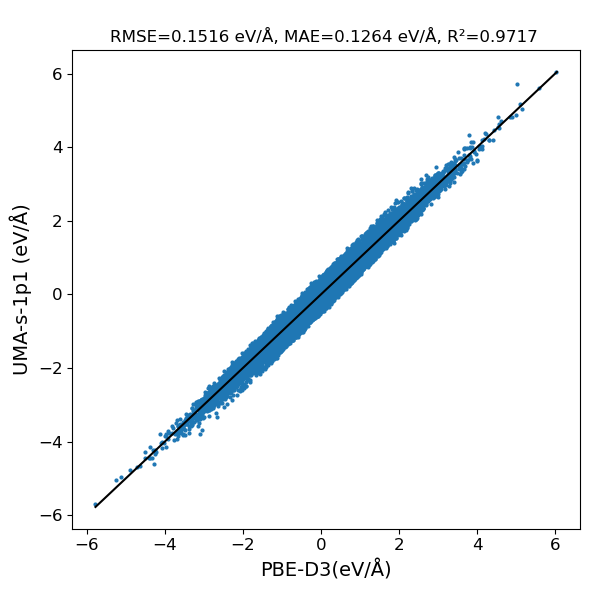

In [35]:
# usage:
metrics = force_parity_plot(frames, n_points=80000)
metrics

In [6]:
import numpy as np
import os
import matplotlib.pyplot as plt

def force_parity_plot_full(frames, ref_key="REF_forces", pred_key="uma_forces",
                           title="Forces parity: UMA vs VASP",
                           outfile="plots/force_parity_data.dat",
                           figfile="plots/force_pbe_uma-s1p1.png"):

    # collect all forces
    Fref_list, Fpred_list = [], []
    for a in frames:
        if ref_key not in a.arrays or pred_key not in a.arrays:
            raise RuntimeError(f"Missing arrays in a frame. Have: {list(a.arrays.keys())}")
        Fref_list.append(np.asarray(a.arrays[ref_key], float))
        Fpred_list.append(np.asarray(a.arrays[pred_key], float))

    Fref = np.vstack(Fref_list)   # (Natoms_total, 3)
    Fpred = np.vstack(Fpred_list)

    # flatten to components
    x = Fref.reshape(-1)
    y = Fpred.reshape(-1)

    # ---------- SAVE FULL DATA ----------
    outdir = os.path.dirname(outfile)
    if outdir:
        os.makedirs(outdir, exist_ok=True)
    data = np.column_stack((x, y))
    np.savetxt(outfile, data, header="REF_force(eV/A)  UMA_force(eV/A)", fmt="%.8f")
    print(f"Saved full force data to: {outfile}")
    # -----------------------------------

    # ---------- FULL METRICS ----------
    d = y - x
    rmse = float(np.sqrt(np.mean(d * d)))
    mae  = float(np.mean(np.abs(d)))

    # R^2 as correlation^2 (common for parity)
    r = float(np.corrcoef(x, y)[0, 1]) if x.size > 1 else float("nan")
    r2 = r * r if np.isfinite(r) else float("nan")
    # ---------------------------------

    mn = float(min(x.min(), y.min()))
    mx = float(max(x.max(), y.max()))

    # ---------- FULL PLOT (NO SUBSET) ----------
    figdir = os.path.dirname(figfile)
    if figdir:
        os.makedirs(figdir, exist_ok=True)

    plt.figure(figsize=(6, 6))
    plt.scatter(x, y, s=1)  # s=1 helps when you have lots of points
    plt.plot([mn, mx], [mn, mx], color="black")
    plt.xlabel("PBE-D3 (eV/Å)", fontsize=14)
    plt.ylabel("UMA-s-1p1 (eV/Å)", fontsize=14)
    plt.title(f"RMSE={rmse:.4g} eV/Å, MAE={mae:.4g} eV/Å, R²={r2:.4g}")
    plt.tick_params(axis='both', labelsize=12)
    plt.tight_layout()
    plt.savefig(figfile, dpi=500)
    # ------------------------------------------

    return {"rmse": rmse, "mae": mae, "r2": r2, "n": int(x.size)}

Saved full force data to: plots/force_parity_data.dat


{'rmse': 0.15146133632376593,
 'mae': 0.12613105370508643,
 'r2': 0.971795588322753,
 'n': 202500}

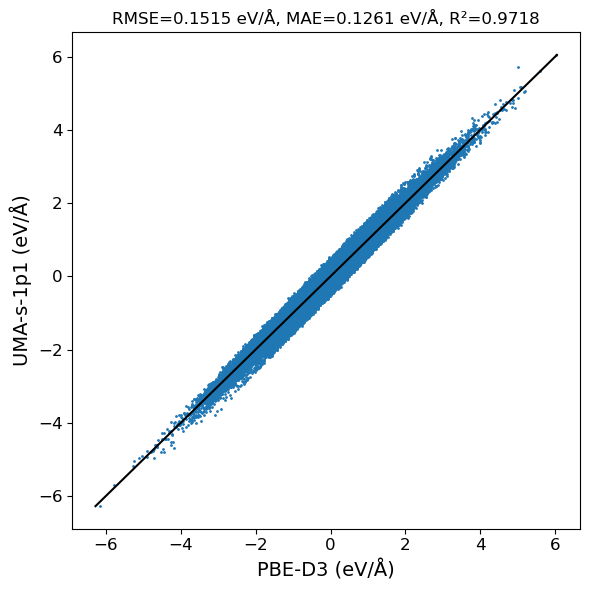

In [7]:
# usage:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
extxyz_path="/Users/tony/Desktop/MIND-Lab/asphaltene-project/uma-validation/toluene/sp_pbe_uma.extxyz"
frames = read(extxyz_path, index=":")
len(frames)
metrics = force_parity_plot_full(frames)
metrics

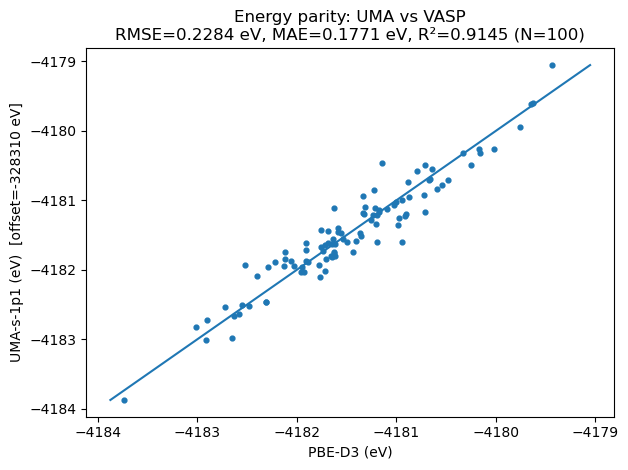

Avg offset (UMA - REF) [eV] = -328310.3348012393


In [14]:

def energy_offset_and_parity(frames, ref_key="REF_energy", pred_key="uma_energy",
                            shift_mode="mean", title="Energy parity: UMA vs VASP"):
    """
    shift_mode:
      - "mean": subtract mean(uma-ref)
      - "median": subtract median(uma-ref) (more robust)
    """
    ref = []
    pred = []
    for a in frames:
        if ref_key not in a.info or pred_key not in a.info:
            raise RuntimeError(f"Missing energies in a frame. Have info: {list(a.info.keys())}")
        ref.append(float(a.info[ref_key]))
        pred.append(float(a.info[pred_key]))

    ref = np.asarray(ref, float)
    pred = np.asarray(pred, float)

    diff = pred - ref  # UMA - REF
    if shift_mode == "mean":
        offset = float(np.mean(diff))
    elif shift_mode == "median":
        offset = float(np.median(diff))
    else:
        raise ValueError("shift_mode must be 'mean' or 'median'")

    pred_shift = pred - offset  # align UMA to REF on average

    # metrics (after shift)
    err = pred_shift - ref
    rmse = float(np.sqrt(np.mean(err**2)))
    mae = float(np.mean(np.abs(err)))

    # R^2
    ss_res = float(np.sum((pred_shift - ref)**2))
    ss_tot = float(np.sum((ref - np.mean(ref))**2))
    r2 = 1.0 - ss_res/ss_tot if ss_tot > 0 else float("nan")

    # parity plot
    mn = float(min(ref.min(), pred_shift.min()))
    mx = float(max(ref.max(), pred_shift.max()))

    plt.figure()
    plt.scatter(ref, pred_shift, s=12)
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("PBE-D3 (eV)")
    plt.ylabel(f"UMA-s-1p1 (eV)  [offset={offset:.6g} eV]")
    plt.title(title + f"\nRMSE={rmse:.4g} eV, MAE={mae:.4g} eV, R²={r2:.4g} (N={len(ref)})")
    plt.tight_layout()
    plt.show()

    return {
        "offset_eV": offset,
        "rmse_eV": rmse,
        "mae_eV": mae,
        "r2": r2,
        "N": int(len(ref)),
        "ref": ref,
        "uma": pred,
        "uma_shifted": pred_shift,
    }

# Usage:
res = energy_offset_and_parity(frames, shift_mode="mean")
print("Avg offset (UMA - REF) [eV] =", res["offset_eV"])